 # Hackathon clasification
 ----
  
  Universidad : UTEC
  Curso       : Machine Learning
  Profesor    : Cristian López Del Alamo
  Tema        : Clasification
  

 ----

 Nombres y  Apellidos de Integrantes: (No olvide poner el % de participacion)
- 1 Ian Kevin Condori Flores - 202310481 (100%)
- 2.Jean Piero Huaylla Huillca - 202310493 (100%)
- 3 Diego Mauricio Marcos Chavez - 202110599 (100%)
- 4.Dicson Marcelo Azalde Lazo - 202210034 (100%)

# Project Title: Credit Card Fraud Detection
----

Objective: The goal of this practice is to build a classification model to detect fraudulent transactions. This problem is particularly challenging because the vast majority of transactions are legitimate, which requires a careful handling of class imbalance. The challenge involves applying and evaluating Logistic Regression, KNN, Decision Trees, and SVM algorithms, paying special attention to how each model handles this challenge.

-----




# Dataset: A public dataset from Kaggle containing credit card transactions is used. It can be accessed via this GitHub URL:


mport kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)



Activities to Complete in Google Colab

----
1. Data Loading and Exploration

- Step 1: Load the Data. Use pandas to load the dataset from the URL.

- Step 2: Initial Exploration. Use df.info() and df.describe() to understand data types and statistics.

- Step 3: Identify Class Imbalance. Calculate the number of fraudulent and legitimate transactions to confirm the imbalance. A bar chart of the target variable (Class) is an excellent way to visualize this.

- Step 4: Separate the Variables. Assign the features (V1 to V28, Amount, Time) to a variable X and the target variable (Class) to a variable y.


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:02<00:00, 24.6MB/s]

Extracting files...


Path to dataset files: C:\Users\Ian\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null

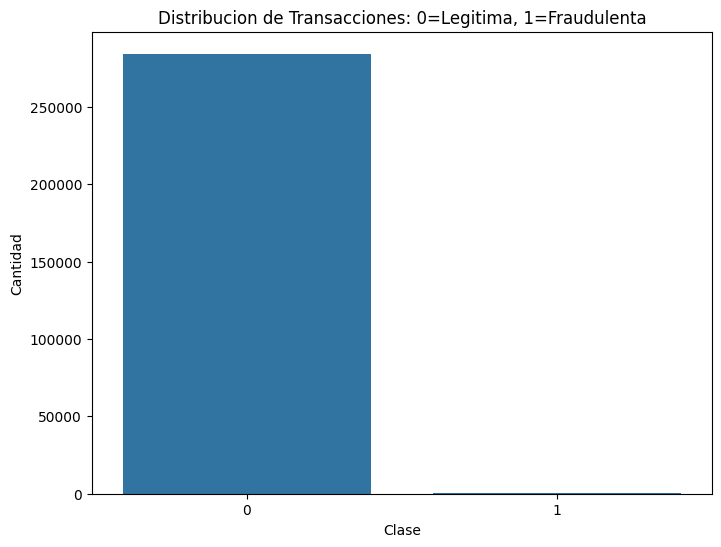


Forma de X: (284807, 30)
Forma de y: (284807,)

Aplicando SMOTE para balancear las clases...
Distribucion original: [284315    492]
Distribucion balanceada: [284315 284315]

Conjunto de entrenamiento: (454904, 30)
Conjunto de prueba: (113726, 30)


In [ ]:
datos = pd.read_csv('./data/creditcard.csv')

print("Informacion del dataset:")
print(datos.info())
print("-"*100)
print("\nEstadisticas descriptivas:")
print(datos.describe())
print("-"*100)

print(f"\nDimensiones del dataset: {datos.shape}")
print(f"\nValores nulos por columna:")
print(datos.isnull().sum())
print("-"*100)

print(f"\nDistribucion de la variable objetivo:")
distribucion_clase = datos['Class'].value_counts()
print(distribucion_clase)
print(f"\nPorcentaje de transacciones legitimas: {distribucion_clase[0]/len(datos)*100:.2f}%")
print(f"Porcentaje de transacciones fraudulentas: {distribucion_clase[1]/len(datos)*100:.2f}%")
print("-"*100)

plt.figure(figsize=(8, 6))
sns.countplot(data=datos, x='Class')
plt.title('Distribucion de Transacciones: 0=Legitima, 1=Fraudulenta')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

X = datos.drop('Class', axis=1)
y = datos['Class']

print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print("\nAplicando SMOTE para balancear las clases...")
smote = SMOTE(random_state=42)
X_balanceado, y_balanceado = smote.fit_resample(X_escalado, y)

print(f"Distribucion original: {np.bincount(y)}")
print(f"Distribucion balanceada: {np.bincount(y_balanceado)}")

X_train, X_test, y_train, y_test = train_test_split(X_balanceado, y_balanceado,
                                                    test_size=0.2, random_state=42,
                                                    stratify=y_balanceado)

print(f"\nConjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")


# 2. Handling Class Imbalance

- Step 1: Understand the problem. Accuracy is not a good metric here. If 99.8% of transactions are legitimate, a model that always predicts "no fraud" would have 99.8% accuracy, which is useless.

- Step 2: Key Evaluation Metrics. It's crucial to focus on metrics like Precision, Recall, and F1-Score. Recall is especially important for this problem, as the goal is to minimize false negatives (fraudulent transactions the model fails to detect).

- Step 3: Sampling Strategies. It's recommended to research and apply a technique to handle the imbalance, such as undersampling or oversampling (for example, with the imblearn library).


## Regresión Logistica

In [ ]:
class RegresionLogistica:
    def __init__(self, tasa_aprendizaje=0.01, iteraciones=1000):
        self.tasa_aprendizaje = tasa_aprendizaje
        self.iteraciones = iteraciones
        self.pesos = None
        self.sesgo = None

    def funcion_sigmoide(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def entrenar(self, X, y):
        n_muestras, n_caracteristicas = X.shape
        self.pesos = np.zeros(n_caracteristicas)
        self.sesgo = 0

        for i in range(self.iteraciones):
            modelo_lineal = np.dot(X, self.pesos) + self.sesgo
            y_predicho = self.funcion_sigmoide(modelo_lineal)

            costo = self.calcular_costo(y, y_predicho)

            dw = (1 / n_muestras) * np.dot(X.T, (y_predicho - y))
            db = (1 / n_muestras) * np.sum(y_predicho - y)

            self.pesos -= self.tasa_aprendizaje * dw
            self.sesgo -= self.tasa_aprendizaje * db

    def calcular_costo(self, y_real, y_predicho):
        y_predicho = np.clip(y_predicho, 1e-15, 1 - 1e-15)
        return -np.mean(y_real * np.log(y_predicho) + (1 - y_real) * np.log(1 - y_predicho))

    def predecir(self, X):
        modelo_lineal = np.dot(X, self.pesos) + self.sesgo
        y_predicho = self.funcion_sigmoide(modelo_lineal)
        predicciones = [1 if i > 0.5 else 0 for i in y_predicho]
        return np.array(predicciones)

## Arbol de Decisión

In [ ]:
class ArbolDecision:
    def __init__(self, profundidad_maxima=10, muestras_minimas=2, min_ganancia=0.01):
        self.profundidad_maxima = profundidad_maxima
        self.muestras_minimas = muestras_minimas
        self.min_ganancia = min_ganancia
        self.raiz = None

    def entrenar(self, X, y):
        self.raiz = self._construir_arbol(X, y, 0)

    def _construir_arbol(self, X, y, profundidad):
        n_muestras, n_caracteristicas = X.shape

        if (profundidad >= self.profundidad_maxima or
            n_muestras < self.muestras_minimas or
            len(np.unique(y)) == 1):
            return self._crear_hoja(y)

        mejor_ganancia = 0
        mejor_division = None

        for caracteristica in range(n_caracteristicas):
            valores = X[:, caracteristica]
            umbrales = np.unique(valores)

            for i in range(len(umbrales) - 1):
                umbral = (umbrales[i] + umbrales[i + 1]) / 2
                ganancia = self._calcular_ganancia(y, valores, umbral)

                if ganancia > mejor_ganancia:
                    mejor_ganancia = ganancia
                    mejor_division = {
                        'caracteristica': caracteristica,
                        'umbral': umbral,
                        'ganancia': ganancia
                    }

        if mejor_ganancia < self.min_ganancia:
            return self._crear_hoja(y)

        caracteristica = mejor_division['caracteristica']
        umbral = mejor_division['umbral']

        indices_izq = X[:, caracteristica] <= umbral
        indices_der = X[:, caracteristica] > umbral

        if np.sum(indices_izq) == 0 or np.sum(indices_der) == 0:
            return self._crear_hoja(y)

        izquierda = self._construir_arbol(X[indices_izq], y[indices_izq], profundidad + 1)
        derecha = self._construir_arbol(X[indices_der], y[indices_der], profundidad + 1)

        return {
            'caracteristica': caracteristica,
            'umbral': umbral,
            'izquierda': izquierda,
            'derecha': derecha,
            'es_hoja': False
        }

    def _crear_hoja(self, y):
        valores, conteos = np.unique(y, return_counts=True)
        clase_mayoritaria = valores[np.argmax(conteos)]
        return {
            'prediccion': clase_mayoritaria,
            'es_hoja': True
        }

    def _calcular_ganancia(self, y, valores_caracteristica, umbral):
        entropia_padre = self._entropia(y)

        indices_izq = valores_caracteristica <= umbral
        indices_der = valores_caracteristica > umbral

        n_total = len(y)
        n_izq = np.sum(indices_izq)
        n_der = np.sum(indices_der)

        if n_izq == 0 or n_der == 0:
            return 0

        entropia_izq = self._entropia(y[indices_izq])
        entropia_der = self._entropia(y[indices_der])

        entropia_hijos = (n_izq / n_total) * entropia_izq + (n_der / n_total) * entropia_der

        return entropia_padre - entropia_hijos

    def _entropia(self, y):
        if len(y) == 0:
            return 0

        _, conteos = np.unique(y, return_counts=True)
        probabilidades = conteos / len(y)

        probabilidades = probabilidades[probabilidades > 0]

        return -np.sum(probabilidades * np.log2(probabilidades))

    def predecir(self, X):
        return np.array([self._predecir_muestra(x, self.raiz) for x in X])

    def _predecir_muestra(self, x, nodo):
        if nodo['es_hoja']:
            return nodo['prediccion']

        if x[nodo['caracteristica']] <= nodo['umbral']:
            return self._predecir_muestra(x, nodo['izquierda'])
        else:
            return self._predecir_muestra(x, nodo['derecha'])

## SVM

In [ ]:
class SVM:
    def __init__(self, tasa_aprendizaje=0.001, lambda_param=0.01, iteraciones=1000):
        self.tasa_aprendizaje = tasa_aprendizaje
        self.lambda_param = lambda_param
        self.iteraciones = iteraciones
        self.w = None
        self.b = None

    def entrenar(self, X, y):
        n_muestras, n_caracteristicas = X.shape

        y_ = np.where(y <= 0, -1, 1)

        self.w = np.zeros(n_caracteristicas)
        self.b = 0

        for i in range(self.iteraciones):
            for idx, x_i in enumerate(X):
                condicion = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condicion:
                    self.w -= self.tasa_aprendizaje * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.tasa_aprendizaje * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.tasa_aprendizaje * y_[idx]

    def predecir(self, X):
        aproximacion = np.dot(X, self.w) - self.b
        return np.sign(aproximacion)

## Optimización de Hiperparametros

In [ ]:
# Nota: Se realizaron la optimizacion de Hiperparametros de forma manual y no con GridSearchCV porque no funciona correctamente con implementaciones manuales (KNN de Sklearn sí uso GridSearchCV)
def grid_search_regresion_logistica(X_train, y_train, X_val, y_val):
    mejores_params = {'tasa_aprendizaje': 0.01, 'iteraciones': 1000}
    mejor_score = 0

    tasas = [0.001, 0.01, 0.1, 0.5]
    iteraciones_lista = [500, 1000, 1500]

    print("\nBuscando mejores hiperparametros para Regresion Logistica...")
    for tasa in tasas:
        for iter_val in iteraciones_lista:
            modelo = RegresionLogistica(tasa_aprendizaje=tasa, iteraciones=iter_val)
            modelo.entrenar(X_train, y_train)
            pred_val = modelo.predecir(X_val)

            tp = np.sum((y_val == 1) & (pred_val == 1))
            fn = np.sum((y_val == 1) & (pred_val == 0))
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0

            if recall > mejor_score:
                mejor_score = recall
                mejores_params = {'tasa_aprendizaje': tasa, 'iteraciones': iter_val}

    print(f"Mejores parametros RL: {mejores_params} (Recall: {mejor_score:.4f})")
    return mejores_params

def grid_search_arbol_decision(X_train, y_train, X_val, y_val):
    mejores_params = {'profundidad_maxima': 5, 'muestras_minimas': 10}
    mejor_score = 0

    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)
    X_val_np = np.array(X_val)
    y_val_np = np.array(y_val)

    muestra_size = int(0.05 * len(X_train_np))
    indices = np.random.choice(len(X_train_np), size=muestra_size, replace=False)
    X_muestra = X_train_np[indices]
    y_muestra = y_train_np[indices]

    profundidades = [5, 8, 10]
    muestras_min = [10, 20]

    print(f"\nBuscando mejores hiperparametros para Arbol de Decision...")
    for prof in profundidades:
        for muestras in muestras_min:
            try:
                modelo = ArbolDecision(
                    profundidad_maxima=prof,
                    muestras_minimas=muestras
                )
                modelo.entrenar(X_muestra, y_muestra)
                pred_val = modelo.predecir(X_val_np)

                tp = np.sum((y_val_np == 1) & (pred_val == 1))
                fn = np.sum((y_val_np == 1) & (pred_val == 0))
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0

                print(f"  Probando prof={prof}, muestras={muestras}, min_gan=0.01 (default), recall={recall:.4f}")

                if recall > mejor_score:
                    mejor_score = recall
                    mejores_params = {
                        'profundidad_maxima': prof,
                        'muestras_minimas': muestras
                    }
            except Exception as e:
                print(f"  Error con prof={prof}, muestras={muestras}: {str(e)}")
                continue

    print(f"Mejores parametros AD: {mejores_params} (Recall: {mejor_score:.4f})")
    return mejores_params

def grid_search_svm(X_train, y_train, X_val, y_val):

    X_train_np = np.array(X_train)
    y_train_np = np.array(y_train)
    X_val_np = np.array(X_val)
    y_val_np = np.array(y_val)

    muestra_size = int(0.20 * len(X_train_np))
    indices = np.random.choice(len(X_train_np), size=muestra_size, replace=False)
    X_muestra = X_train_np[indices]
    y_muestra = y_train_np[indices]

    parametros = [
        {'tasa_aprendizaje': 0.001, 'lambda_param': 0.01, 'iteraciones': 500},
        {'tasa_aprendizaje': 0.001, 'lambda_param': 0.1, 'iteraciones': 500},
        {'tasa_aprendizaje': 0.01, 'lambda_param': 0.01, 'iteraciones': 500},
        {'tasa_aprendizaje': 0.01, 'lambda_param': 0.1, 'iteraciones': 500}
    ]

    mejor_score = 0
    mejores_params = parametros[0]

    for i, params in enumerate(parametros):
        print(f"  Probando {i+1}/4: {params}")

        modelo = SVM(**params)
        modelo.entrenar(X_muestra, y_muestra)
        pred_val_raw = modelo.predecir(X_val_np)
        pred_val = np.where(pred_val_raw <= 0, 0, 1)

        tp = np.sum((y_val_np == 1) & (pred_val == 1))
        fn = np.sum((y_val_np == 1) & (pred_val == 0))
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        print(f"    Recall: {recall:.4f}")

        if recall > mejor_score:
            mejor_score = recall
            mejores_params = params

    print(f"Mejores parametros SVM: {mejores_params} (Recall: {mejor_score:.4f})")
    return mejores_params

def calcular_metricas(y_real, y_predicho):
    tp = np.sum((y_real == 1) & (y_predicho == 1))
    tn = np.sum((y_real == 0) & (y_predicho == 0))
    fp = np.sum((y_real == 0) & (y_predicho == 1))
    fn = np.sum((y_real == 1) & (y_predicho == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return precision, recall, f1_score, accuracy

In [ ]:
def matriz_confusion(y_test, y_pred, modelo_nombre):
    """
    Crea una matriz de confusión visual mejorada para detección de fraude
    """
    matrix = confusion_matrix(y_test, y_pred)

    matrix_norm = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

    df_matrix = pd.DataFrame(
        matrix_norm,
        index=["Legítima", "Fraudulenta"],
        columns=["Legítima", "Fraudulenta"]
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        df_matrix,
        annot=True,
        fmt='.3f',
        cbar=True,
        cmap="Blues",
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )

    plt.title(f"Matriz de Confusión - {modelo_nombre}", fontsize=14, fontweight='bold')
    plt.xlabel("Predicción", fontsize=12)
    plt.ylabel("Valor Real", fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"\nValores absolutos para {modelo_nombre}:")
    print(f"Verdaderos Negativos (TN): {matrix[0,0]}")
    print(f"Falsos Positivos (FP): {matrix[0,1]}")
    print(f"Falsos Negativos (FN): {matrix[1,0]}")
    print(f"Verdaderos Positivos (TP): {matrix[1,1]}")

def graficar_costos_optimizacion(costos_tiempo, data_values, titulo="Costo de Optimización de Hiperparámetros", subtitulo="Tiempo de Grid Search por Modelo"):
    import matplotlib.pyplot as plt
    import numpy as np

    costos_minutos = {k: v/60 for k, v in costos_tiempo.items()}

    print(f"{data_values}")
    print("="*50)
    for modelo, tiempo_min in costos_minutos.items():
        mins = int(tiempo_min)
        secs = (tiempo_min - mins) * 60
        print(f"{modelo:20}: {mins:2d}m {secs:05.2f}s")

    plt.figure(figsize=(12, 8))

    modelos = list(costos_minutos.keys())
    tiempos = list(costos_minutos.values())

    colores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

    if len(modelos) > len(colores):
        colores = plt.cm.Set3(np.linspace(0, 1, len(modelos)))
    elif len(modelos) < len(colores):
        colores = colores[:len(modelos)]

    barras = plt.bar(modelos, tiempos, color=colores, alpha=0.8,
                     edgecolor='black', linewidth=1.2)

    plt.title(f'{titulo}\n{subtitulo}',
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Tiempo (minutos)', fontsize=12, fontweight='bold')
    plt.xlabel('Modelos de Machine Learning', fontsize=12, fontweight='bold')

    plt.xticks(rotation=45, ha='right')

    for i, (barra, tiempo) in enumerate(zip(barras, tiempos)):
        mins = int(tiempo)
        secs = (tiempo - mins) * 60
        plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + max(tiempos)*0.01,
                 f'{mins}m {secs:.1f}s',
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

    promedio = np.mean(tiempos)
    plt.axhline(y=promedio, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.text(len(modelos)-1, promedio + max(tiempos)*0.02,
             f'Promedio: {promedio:.1f} min',
             ha='right', va='bottom', color='red', fontweight='bold')

    plt.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    plt.tight_layout()

    plt.show()


# 3. Modeling and Evaluation

- Step 1: Split the Data. Split the X and y datasets into training and testing sets.

- Step 2: Train the Models. Train the four classification models: Logistic Regression, K-Nearest Neighbors (KNN), Decision Trees, Support Vector Machine (SVM)

- Step 3: Evaluate Performance. For each model, use the test set to make predictions. Then, calculate and display the Precision, Recall, and F1-Score metrics using the classification_report.

- Step 4: Comparison and Conclusion. Present a comparative table of the metrics. The best model for this problem should be argued, based primarily on the recall of the minority class (fraud), as it's the most critical metric in this context.

## Busqueda de mejores parametros

In [ ]:
X_train_grid, X_val_grid, y_train_grid, y_val_grid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
# Mejores Hiperparametros Regresión Logistica
mejores_params_rl = grid_search_regresion_logistica(X_train_grid, y_train_grid, X_val_grid, y_val_grid)


Buscando mejores hiperparametros para Regresion Logistica...
Mejores parametros RL: {'tasa_aprendizaje': 0.001, 'iteraciones': 500} (Recall: 0.9591)


In [ ]:
# Mejores Hiperparametrros Arbol de Decisión
mejores_params_ad = grid_search_arbol_decision(X_train_grid, y_train_grid, X_val_grid, y_val_grid)


Buscando mejores hiperparametros para Arbol de Decision...
  Probando prof=5, muestras=10, min_gan=0.01 (default), recall=0.9500
  Probando prof=5, muestras=10, min_gan=0.01 (default), recall=0.9500
  Probando prof=5, muestras=20, min_gan=0.01 (default), recall=0.9500
  Probando prof=5, muestras=20, min_gan=0.01 (default), recall=0.9500
  Probando prof=8, muestras=10, min_gan=0.01 (default), recall=0.9710
  Probando prof=8, muestras=10, min_gan=0.01 (default), recall=0.9710
  Probando prof=8, muestras=20, min_gan=0.01 (default), recall=0.9695
  Probando prof=8, muestras=20, min_gan=0.01 (default), recall=0.9695
  Probando prof=10, muestras=10, min_gan=0.01 (default), recall=0.9814
  Probando prof=10, muestras=10, min_gan=0.01 (default), recall=0.9814
  Probando prof=10, muestras=20, min_gan=0.01 (default), recall=0.9786
Mejores parametros AD: {'profundidad_maxima': 10, 'muestras_minimas': 10} (Recall: 0.9814)
  Probando prof=10, muestras=20, min_gan=0.01 (default), recall=0.9786
Mejor

In [ ]:
# Mejores Hiperparametros SVM
mejores_params_svm = grid_search_svm(X_train_grid, y_train_grid, X_val_grid, y_val_grid)

  Probando 1/4: {'tasa_aprendizaje': 0.001, 'lambda_param': 0.01, 'iteraciones': 500}
    Recall: 0.8940
  Probando 2/4: {'tasa_aprendizaje': 0.001, 'lambda_param': 0.1, 'iteraciones': 500}
    Recall: 0.8719
  Probando 3/4: {'tasa_aprendizaje': 0.01, 'lambda_param': 0.01, 'iteraciones': 500}
    Recall: 0.9058
  Probando 4/4: {'tasa_aprendizaje': 0.01, 'lambda_param': 0.1, 'iteraciones': 500}
    Recall: 0.8765
Mejores parametros SVM: {'tasa_aprendizaje': 0.01, 'lambda_param': 0.01, 'iteraciones': 500} (Recall: 0.9058)


In [ ]:
# Mejores Hiperparametros KNN con GridSearchCV
print("\nBuscando mejores hiperparametros para KNN con GridSearchCV...")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(
    knn,
    param_grid_knn,
    cv=3,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train_grid, y_train_grid)
mejores_params_knn = grid_search_knn.best_params_
mejor_score_knn = grid_search_knn.best_score_

print(f"Mejores parametros KNN: {mejores_params_knn}")
print(f"Mejor Recall KNN: {mejor_score_knn:.4f}")


Buscando mejores hiperparametros para KNN con GridSearchCV...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Mejores parametros KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Mejor Recall KNN: 1.0000
Mejores parametros KNN: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Mejor Recall KNN: 1.0000


COSTO DE OPTIMIZACIÓN DE HIPERPARÁMETROS:
Regresión Logística :  3m 11.70s
Árbol de Decisión   : 33m 58.50s
SVM                 :  5m 12.20s
KNN                 : 22m 33.70s


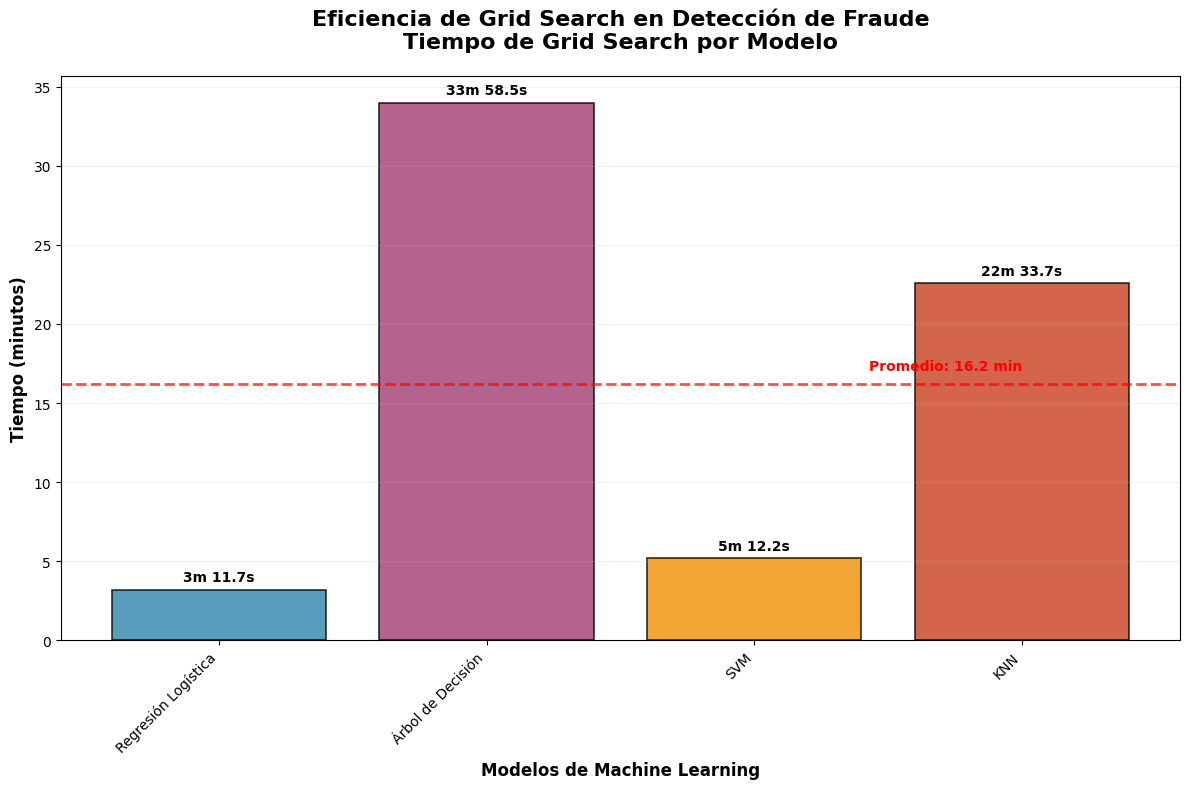

In [ ]:
# Costo de optimizacion de Hiperparametros
resultados_costos = graficar_costos_optimizacion(
    costos_tiempo,
    data_values="COSTO DE OPTIMIZACIÓN DE HIPERPARÁMETROS:",
    titulo="Eficiencia de Grid Search en Detección de Fraude",
    subtitulo="Tiempo de Grid Search por Modelo"
)

## Entrenamiento con mejores Hiperparametros

In [ ]:

print("\nEntrenando KNN con mejores parametros...")
modelo_knn = KNeighborsClassifier(**mejores_params_knn)
modelo_knn.fit(X_train, y_train)
predicciones_knn = modelo_knn.predict(X_test)
print("Entrenamiento de KNN completado")


Entrenando KNN con mejores parametros...
Entrenamiento de KNN completado
Entrenamiento de KNN completado


In [ ]:
print("\nEntrenando Regresion Logistica con mejores parametros...")
modelo_reglog = RegresionLogistica(
    tasa_aprendizaje=mejores_params_rl['tasa_aprendizaje'],
    iteraciones=mejores_params_rl['iteraciones']
)
modelo_reglog.entrenar(X_train, y_train)
predicciones_reglog = modelo_reglog.predecir(X_test)
print("Entrenamiento de Regresion Logistica completado")


Entrenando Regresion Logistica con mejores parametros...
Entrenamiento de Regresion Logistica completado
Entrenamiento de Regresion Logistica completado


In [ ]:
print("\nEntrenando Arbol de Decision con mejores parametros...")
modelo_arbol = ArbolDecision(
    profundidad_maxima=mejores_params_ad['profundidad_maxima'],
    muestras_minimas=mejores_params_ad['muestras_minimas'],
    min_ganancia=mejores_params_ad.get('min_ganancia', 0.01)
)
modelo_arbol.entrenar(X_train, y_train)
predicciones_arbol = modelo_arbol.predecir(X_test)
print("Entrenamiento de Arbol de Decision completado")


Entrenando Arbol de Decision con mejores parametros...
Entrenamiento de Arbol de Decision completado
Entrenamiento de Arbol de Decision completado


In [ ]:
print("\nEntrenando SVM con mejores parametros...")
modelo_svm = SVM(
    tasa_aprendizaje=mejores_params_svm['tasa_aprendizaje'],
    lambda_param=mejores_params_svm['lambda_param'],
    iteraciones=mejores_params_svm['iteraciones']
)
modelo_svm.entrenar(X_train, y_train)
predicciones_svm_raw = modelo_svm.predecir(X_test)
predicciones_svm = np.where(predicciones_svm_raw <= 0, 0, 1)
print("Entrenamiento de SVM completado")


Entrenando SVM con mejores parametros...
Entrenamiento de SVM completado
Entrenamiento de SVM completado


COSTO DE ENTRENAMIENTO DE MODELOS:
Regresión Logística :  0m 09.70s
Árbol de Decisión   :  0m 15.20s
SVM                 :  7m 55.40s
KNN                 :  0m 15.10s


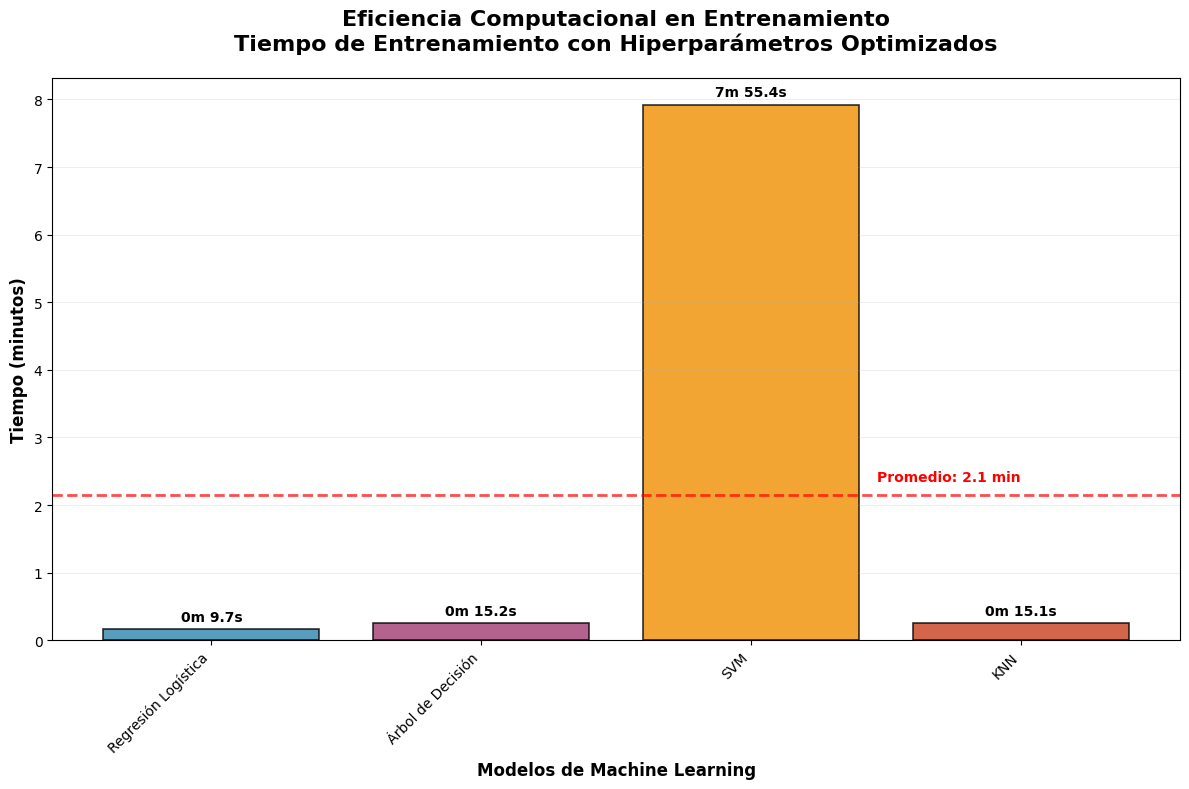

In [ ]:
# Comparación Tiempo de entrenamiento (Con mejores parametros)
resultados_costos = graficar_costos_optimizacion(
    costos_tiempo,
    data_values="COSTO DE ENTRENAMIENTO DE MODELOS:",
    titulo="Eficiencia Computacional en Entrenamiento",
    subtitulo="Tiempo de Entrenamiento con Hiperparámetros Optimizados"
)

## Evaluación de Performance

In [ ]:
print("Usando classification_report para calcular Precision, Recall y F1-Score:")

print("\n1. KNN (K-NEAREST NEIGHBORS)")
print("Classification Report:")
print(classification_report(y_test, predicciones_knn, target_names=['Legitima', 'Fraudulenta']))

print("\n2. REGRESION LOGISTICA")
print("Classification Report:")
print(classification_report(y_test, predicciones_reglog, target_names=['Legitima', 'Fraudulenta']))

print("\n3. ARBOL DE DECISION")
print("Classification Report:")
print(classification_report(y_test, predicciones_arbol, target_names=['Legitima', 'Fraudulenta']))

print("\n4. SVM")
print("Classification Report:")
print(classification_report(y_test, predicciones_svm, target_names=['Legitima', 'Fraudulenta']))

## Metricas
precision_knn, recall_knn, f1_knn, accuracy_knn = calcular_metricas(y_test, predicciones_knn)
precision_rl, recall_rl, f1_rl, accuracy_rl = calcular_metricas(y_test, predicciones_reglog)
precision_ad, recall_ad, f1_ad, accuracy_ad = calcular_metricas(y_test, predicciones_arbol)
precision_svm, recall_svm, f1_svm, accuracy_svm = calcular_metricas(y_test, predicciones_svm)

Usando classification_report para calcular Precision, Recall y F1-Score:

1. KNN (K-NEAREST NEIGHBORS)
Classification Report:
              precision    recall  f1-score   support

    Legitima       1.00      1.00      1.00     56863
 Fraudulenta       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726


2. REGRESION LOGISTICA
Classification Report:
              precision    recall  f1-score   support

    Legitima       0.96      0.87      0.91     56863
 Fraudulenta       0.88      0.96      0.92     56863

    accuracy                           0.91    113726
   macro avg       0.92      0.91      0.91    113726
weighted avg       0.92      0.91      0.91    113726


3. ARBOL DE DECISION
Classification Report:
              precision    recall  f1-score   support

    Legitima       0.99      0.98      0.99     56863
 Fraudulenta       

## Comparación y Conclusión

Tabla comparativa de metricas:
                Modelo  Precision  Recall  F1-Score  Accuracy
0                  KNN     0.9985  1.0000    0.9993    0.9993
1  Regresion Logistica     0.8794  0.9596    0.9177    0.9140
2    Arbol de Decision     0.9836  0.9886    0.9861    0.9860
3                  SVM     0.9691  0.9081    0.9376    0.9396

=== MEJOR MODELO PARA DETECCION DE FRAUDE ===
Modelo: KNN
Recall: 1.0000
Precision: 0.9985
F1-Score: 0.9993

=== MATRICES DE CONFUSION ===


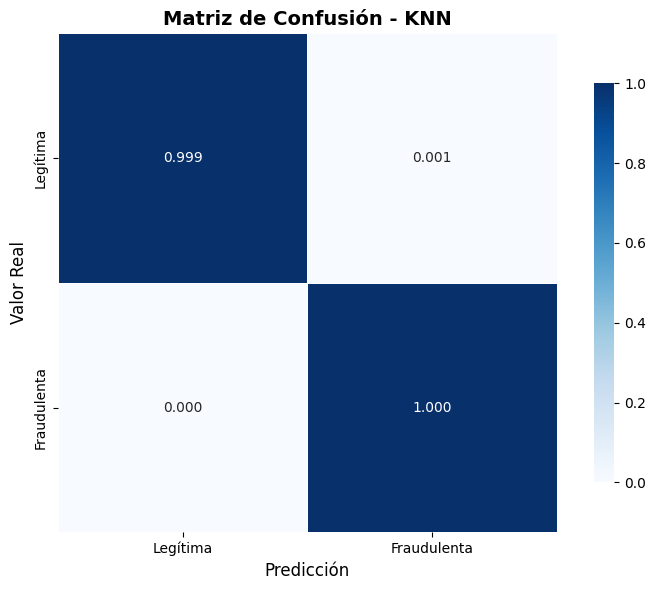


Valores absolutos para KNN:
Verdaderos Negativos (TN): 56778
Falsos Positivos (FP): 85
Falsos Negativos (FN): 0
Verdaderos Positivos (TP): 56863


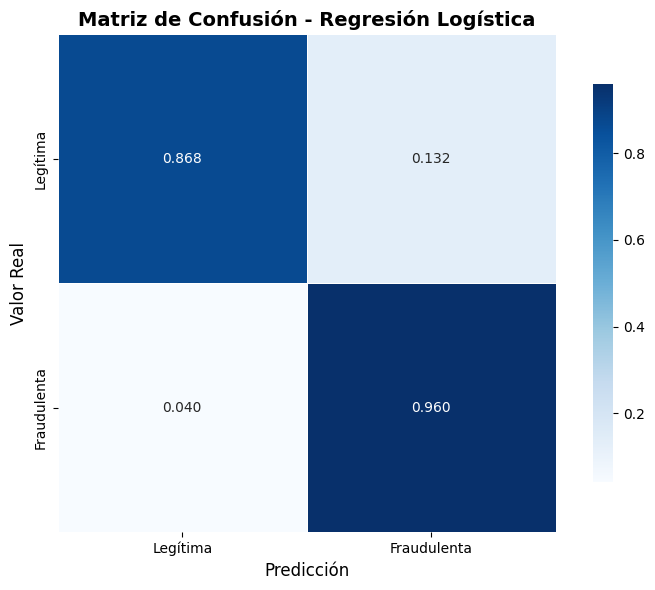


Valores absolutos para Regresión Logística:
Verdaderos Negativos (TN): 49378
Falsos Positivos (FP): 7485
Falsos Negativos (FN): 2300
Verdaderos Positivos (TP): 54563


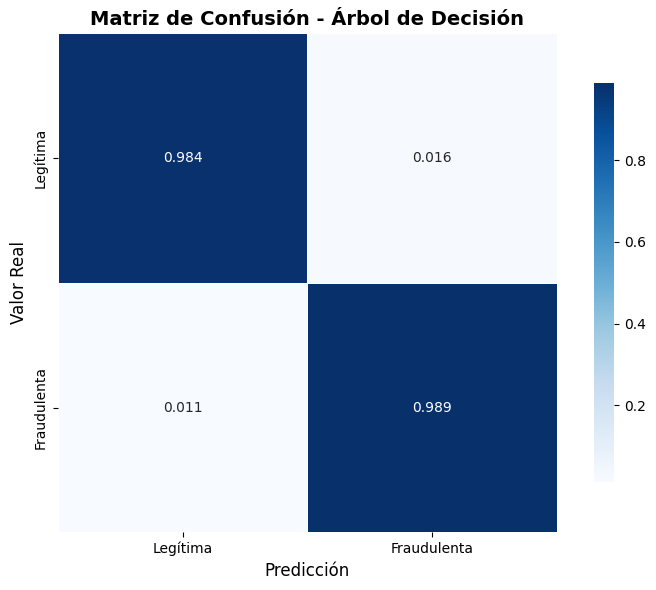


Valores absolutos para Árbol de Decisión:
Verdaderos Negativos (TN): 55925
Falsos Positivos (FP): 938
Falsos Negativos (FN): 649
Verdaderos Positivos (TP): 56214


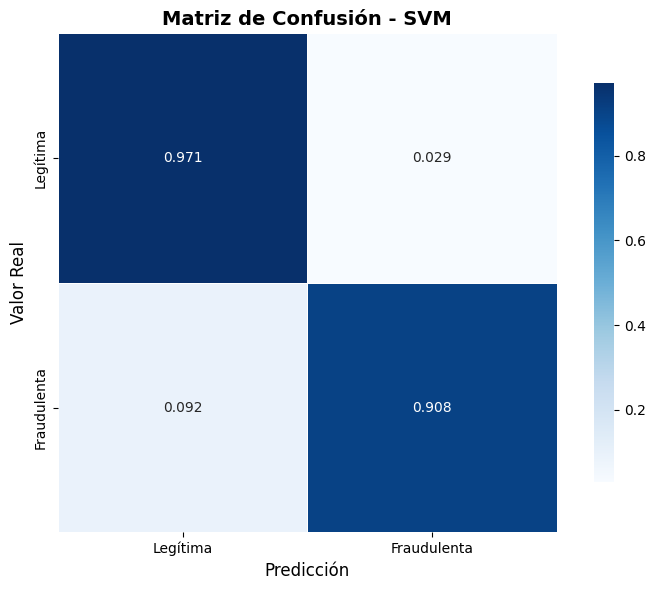


Valores absolutos para SVM:
Verdaderos Negativos (TN): 55217
Falsos Positivos (FP): 1646
Falsos Negativos (FN): 5226
Verdaderos Positivos (TP): 51637


In [ ]:
print("Tabla comparativa de metricas:")

resultados = pd.DataFrame({
    'Modelo': ['KNN', 'Regresion Logistica', 'Arbol de Decision', 'SVM'],
    'Precision': [precision_knn, precision_rl, precision_ad, precision_svm],
    'Recall': [recall_knn, recall_rl, recall_ad, recall_svm],
    'F1-Score': [f1_knn, f1_rl, f1_ad, f1_svm],
    'Accuracy': [accuracy_knn, accuracy_rl, accuracy_ad, accuracy_svm]
})

print(resultados.round(4))

mejor_recall = resultados.loc[resultados['Recall'].idxmax()]
print(f"\n=== MEJOR MODELO PARA DETECCION DE FRAUDE ===")
print(f"Modelo: {mejor_recall['Modelo']}")
print(f"Recall: {mejor_recall['Recall']:.4f}")
print(f"Precision: {mejor_recall['Precision']:.4f}")
print(f"F1-Score: {mejor_recall['F1-Score']:.4f}")

print(f"\n=== MATRICES DE CONFUSION ===")
matriz_confusion(y_test, predicciones_knn, "KNN")
matriz_confusion(y_test, predicciones_reglog, "Regresión Logística")
matriz_confusion(y_test, predicciones_arbol, "Árbol de Decisión")
matriz_confusion(y_test, predicciones_svm, "SVM")

# Conclusiones